## Libraries

In [1]:
# General
import numpy as np
import math
import pandas as pd


# Symbolic computation
import sympy
# Integration
import scipy.integrate as integrate
# Interpolation
from scipy.interpolate import interp1d
# Confidence intervals
from scipy import stats
# Solving non-linear equations
from scipy.optimize import fsolve
# Non uniform Fourier transform
# import finufft
# Timing functions
import time
# Random numbers
import random

# Plotting
import seaborn as sns 
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})

## Generating functions

The behaviour of the process is imputed from the generating functions specified below.

In [8]:
# Root ancestor type
i0 = 1
# Sample size
k = 2

# Type 1
def generating1(f_1, f_2):
    return math.exp(1)**(-4*(1-f_1)-2*(1-f_2))

# Type 2
def generating2(f_1, f_2):
    return math.exp(1)**(-1*(1-f_1)-3*(1-f_2))

### Mean offspring matrix creation

In [ ]:
# Placeholders for highest derivative
y1 = sympy.Symbol("y1")
y2 = sympy.Symbol("y2")
# All helper variables
ys = [y1, y2]

# Mean offspring matrix
offspring_exp = np.zeros((2,2))

# All generating functions
generatings = [generating1, generating2]

The expected value of a random variable $X$ can be calculated from its probability generating function, $f(s)$, by calculating $f'(1)$.

In [9]:
# Calculating the expected value of the number of offspring from the generating functions
for parent in range(1, 3):
    current_gen = generatings[parent-1]
    for offspring in range(1, 3):
        y = ys[offspring-1]
        if offspring == 1:
            gen_symbolic = current_gen(y, 1)
        else:
            gen_symbolic = current_gen(1, y)
        gen_der = gen_symbolic.diff(y, 1)
        offspring_exp[parent-1, offspring-1] = gen_der.subs(y, 1)


## Dynamics of the branching process

Caclulating the eigendecomposition of the mean offspring matrix. We will denote the maximal eigenvalue with $\lambda$.

In [12]:
# Eigen decomposition
eig_values, right_vectors = np.linalg.eig(offspring_exp)
_, left_vectors = np.linalg.eig(offspring_exp.transpose())
# Picking which index corresponds to the maximum eigenvalue
which_max_eigen = eig_values.argmax()
max_eigen = eig_values[which_max_eigen]
# Eigenvectors corresponding to the leading eigenvalue
right_vector = right_vectors[:, which_max_eigen]
left_vector = left_vectors[:, which_max_eigen]
# Scaling so that the left eigenvector sums up to 1
sum_left = sum(left_vector)
l = left_vector/sum_left
scaling = sum(right_vector*l)
r = right_vector/scaling

## Extinction

Calculating the extinction probabilities based on the identity $f(q)=q$.

In [14]:
def extinction_eq(vars):
    x, y = vars
    eq1 = generating1(x, y) - x
    eq2 = generating2(x, y) - y
    return [eq1, eq2]

initial_guess = [0,0]

qs = fsolve(extinction_eq, initial_guess)

# Calculating the distribution of Z from the generating functions

The joint distribution of $Z_1^{i_0, 1}$ and $Z_1^{i_0, 2}$ will be calculated from the generating functions. The matrix describing it will be truncated when the sum of probabilities in it exceeds a threshold of 0.9999.

In [16]:
# Computing the matrix describing the joint distribution up to a maximum 
# number of offspring given by max_offspring.
def compute_dist(gener):
    prob_matrix = np.zeros((max_offspring, max_offspring))
    for i in range(max_offspring):
        for j in range(max_offspring):
            deriv = (gener.diff(y1, i)).diff(y2, j).subs(y1, 0).subs(y2, 0)
    #         Remove derivative multipliers
            prob_matrix[i,j] = deriv/math.factorial(i)/math.factorial(j)
        return prob_matrix

In [17]:
# Placeholder variables
enough1 = True
enough2 = True
# The matrix has to be big enough to have most of the probability
max_offspring = 1
# What proportion of probability we want in the dsitribution matrix
threshold = 0.9999

while enough1 and enough2:
    prob_matrix = []
    all_probs = []
    for i in range(2):
        current_matrix = compute_dist(generatings[i](y1, y2))
        # If rounding errors make them negative, replace with 0
        current_matrix[current_matrix < 0] = 0
#         We only stop when the sum of probabilities exceeds the threshold for both types
        if i == 0 and current_matrix.sum() > threshold:
            enough1 = False
        if i == 1 and current_matrix.sum() > threshold:
            enough2 = False
        prob_matrix.append(current_matrix)
        # flattening the population size probabilities for sampling purposes
        current_probs = current_matrix.flatten()
        # the probabilities will not sum up to 1, so rescaling for them to sum up to 1 for the code to work
        probs_normalised = current_probs/sum(current_probs)
#         print("The matrix entries sum up to " + str(round(sum(current_probs), 4)))
        all_probs.append(probs_normalised)
#     Only increase maximum number of offspring if condition has not yet been satisfied
    if enough1 and enough2:
        max_offspring += 1

# print("Size of matrix: " + str(max_offspring))

The matrix entries sum up to 0.0025
The matrix entries sum up to 0.0183
The matrix entries sum up to 0.0372
The matrix entries sum up to 0.1465
The matrix entries sum up to 0.1611
The matrix entries sum up to 0.3892
The matrix entries sum up to 0.3715
The matrix entries sum up to 0.6349
The matrix entries sum up to 0.5957
The matrix entries sum up to 0.8123
The matrix entries sum up to 0.7721
The matrix entries sum up to 0.9155
The matrix entries sum up to 0.8853
The matrix entries sum up to 0.9664
The matrix entries sum up to 0.9478
The matrix entries sum up to 0.9881
The matrix entries sum up to 0.9784
The matrix entries sum up to 0.9962
The matrix entries sum up to 0.9918
The matrix entries sum up to 0.9989
The matrix entries sum up to 0.9972
The matrix entries sum up to 0.9997
The matrix entries sum up to 0.9991
The matrix entries sum up to 0.9999
The matrix entries sum up to 0.9997
The matrix entries sum up to 1.0
The matrix entries sum up to 0.9999
The matrix entries sum up to 1.

### Constants

In [19]:
# The argument to the moment generating function
s = sympy.Symbol("s")
# Moment generating functions
phi1 = sympy.Function("phi1")
phi2 = sympy.Function("phi2")

# Number of moments to calculate
max_derivative = 10

# Set of points close to 0
points0 = np.linspace(0.01, 0.01*max_eigen, 10)

# Error bars
t = stats.t.ppf(1-0.025, 999)

### Helper Functions

For supercritical processes, it holds that $\phi(\lambda s) = f(\phi(s))$. 

In [20]:
# Vectorised factorial function
factorial = np.vectorize(math.factorial)

# Derivative of the left hand side of the equation above
def lhs_derivative(equation, n):
    return max_eigen**n * equation.diff(s,n)

### Estimating coefficients in the power series expansion of the moment generating function

We are going to estimate the $n$-th moment of $W$ by recursively computing the $n$-th derivative of $\phi(\lambda s)=f(\phi(s))$ and evaluating it at 0.

In [21]:
# Matrix for the estimated coefficients
estim1 = np.full((1,max_derivative), r[0])
estim2 = np.full((1,max_derivative), r[1])
estim_mat = np.concatenate((estim1, estim2), axis=0)
# Dictionary for choosing the row in the estimated coefficients matrix
dict_index = {"phi1": 0, "phi2": 1}
# Dictionary for replacing derivatives with unknown variables
dict_var = {"phi1": y1, "phi2": y2}

# Compute the nth derivative of th equation above
def differentiate(lhs, rhs, diff):
    der_r = rhs.diff(s, diff)
    der_l = lhs_derivative(lhs, diff)
    der = der_l - der_r
#     Replace all derivatives of lower order than the current index with already known values
    for replace_der in range(1, diff):
        der = der.replace(sympy.Derivative(phi1(s), (s, replace_der)), estim_mat[dict_index["phi1"],replace_der-1])
        der = der.replace(sympy.Derivative(phi2(s), (s, replace_der)), estim_mat[dict_index["phi2"],replace_der-1])
    second_der1 = der.replace(sympy.Derivative(phi1(s), (s,diff)), dict_var["phi1"])
    second_der2 = second_der1.replace(sympy.Derivative(phi2(s), (s,diff)), dict_var["phi2"])
#     Replace the value of the function at 0 with 1
    zero_der1 = second_der2.replace(phi1(s), 1)
    zero_der2 = zero_der1.replace(phi2(s), 1)
    return zero_der2

# Estimate the coefficients
for der in range(2, max_derivative+1):
    eq1 = differentiate(phi1(s), generating1(phi1(s),phi2(s)),  der)
    eq2 = differentiate(phi2(s), generating2(phi2(s), phi1(s)), der)
    solutions = sympy.nsolve((eq1, eq2), (y1, y2), (0, 0))
    for i in range(len(estim_mat)):
        estim_mat[i,der-1] = solutions[i]

# Add constant 1 at start and divide by factorials
estim_mat = np.concatenate((np.ones((len(estim_mat),1)), estim_mat), axis = 1)/factorial(np.arange(max_derivative+1))

# The estimated moment generating/characteristic function
def func(y, index = 0):
#     (-y) because -it
    x_power = (-y*1j)**np.arange(max_derivative+1)
    return np.sum(estim_mat[index, :] * x_power)

vectorized_func = np.vectorize(func)

# Characteristic function

We first calculate the values on the interval $t_0 < t < \lambda$ using the Taylor approximation. Then we use the equation $\phi(\lambda s) = f(\phi(s))$ to calculate the values of the characteristic function further away from 0. 

In [24]:
# How many powers of the leading eigenvalue we are interested in
reps = 25
# Small positive and negative values
for pos_neg in [-1, 1]: 
    for i in range(0, reps):
        if pos_neg == -1 and i == 0:
#             Setting the array for the results
            points_harris = np.array([pos_neg*points0, vectorized_func(-points0), 
                                      vectorized_func(-points0, index=1)])
        else:
            new_points = pos_neg*points0*(max_eigen**i)  
#             If the first of positive numbers, use the series approximation to compute the values
            if i == 0:
                new_array = np.array([new_points, vectorized_func(new_points), vectorized_func(new_points, index=1)])
            else:
#                 Otherwise, use equation above to compute the values
                index_before = int(len(points0)*reps*(pos_neg+1)/2+len(points0)*(i-1))
                last_points = points_harris[:,index_before:(index_before+len(points0))]
                new_array = np.array([new_points, generating1(last_points[1,:], last_points[2,:]), 
                                      generating2(last_points[1,:], last_points[2,:])])
            points_harris = np.concatenate((points_harris, new_array), axis=1)

# Ordering the points 
in_order = np.argsort(points_harris[0,:].real)
points_ordered = points_harris[:,in_order]

Subtracting the extinction probability from the estimated characteristic function gives the continuous part of the denstiy.

\begin{equation}
\mathbb{E}(e^{-isW}) = \mathbb{E}(e^{-isW}|W=0)\mathbb{P}(W=0) + \mathbb{E}(e^{-isW}|W>0)(1-\mathbb{P}(W=0)) = q+(1-q)\mathbb{E}(e^{-isW}|W>0)
\end{equation}

and hence 

\begin{equation}
(1-q)\mathbb{E}(e^{-isW}|W>0) = \mathbb{E}(e^{-isW}) -q
\end{equation}

which is plotted below.

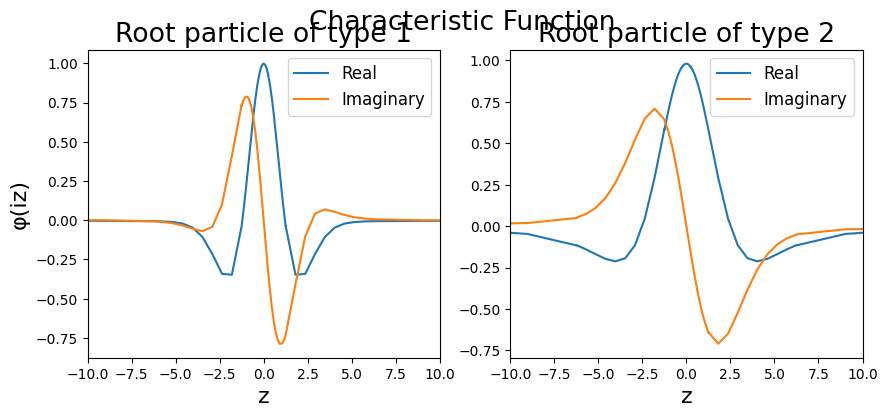

In [26]:
x_plot = sorted(points_harris[0,:].real)
y_plot1 = points_harris[1,np.argsort(points_harris[0,:])] - qs[0]
y_plot2 = points_harris[2,np.argsort(points_harris[0,:])] - qs[1]
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
axes[0].plot(x_plot, y_plot1.real, label = "Real")
axes[0].plot(x_plot, y_plot1.imag, label = "Imaginary")
axes[1].plot(x_plot, y_plot2.real, label = "Real")
axes[1].plot(x_plot, y_plot2.imag, label = "Imaginary")
for i in range(2):
    axes[i].set_title("Root particle of type "+str(i+1))
    axes[i].legend(fontsize=12)
    axes[i].set_xlabel("z")
    axes[i].tick_params(axis="both", labelsize=10)
axes[0].set_ylabel("φ(iz)")
plt.setp(axes, xlim=(-10, 10))
# plt.savefig('char_func.pdf', bbox_inches='tight')
fig.suptitle("Characteristic Function")
plt.show()

# Inverse Fourier Transform

In [27]:
def fourier_invert(y, lim):
#     Interpolate the estimated desnsity to uniformly spaced points
    interp_func = interp1d(points_harris[0,], y)
    # Make sure it actually has 0 in the range.
    # Choosing more points just makes the interval after inverting longer, it doesn't affect the granularity
    equal_spaced = np.linspace(-lim, lim, 10000, endpoint=False)
    interpolated = interp_func(equal_spaced)
    # Step size before transformation
    step = abs(equal_spaced[0] - equal_spaced[1])
    # Inverse Fourier Transform 
    f_og = np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(interpolated)))*len(equal_spaced)*step/(2*np.pi) # Normalisation constants
    # fftfreq creates bins for the new x axis, ffshift makes them ordered by value. 
    x_range = np.fft.fftshift(np.fft.fftfreq(len(equal_spaced), d=step))*2*np.pi
    return x_range, f_og    

In [28]:
# Density for type 1
x_range, f_og1 = fourier_invert(points_harris[1,]-qs[0], 2500)
# Density of type 2
x_range, f_og2 = fourier_invert(points_harris[2,]-qs[1], 2500)

In [30]:
print("The sampling rate in the time domain:" + str(round(abs(x_range[0]-x_range[1]), 4)))

The sampling rate in the time domain:0.0013


The range of the inverted density.

In [31]:
x_range

array([-6.28318531, -6.28192867, -6.28067203, ...,  6.2794154 ,
        6.28067203,  6.28192867], shape=(10000,))

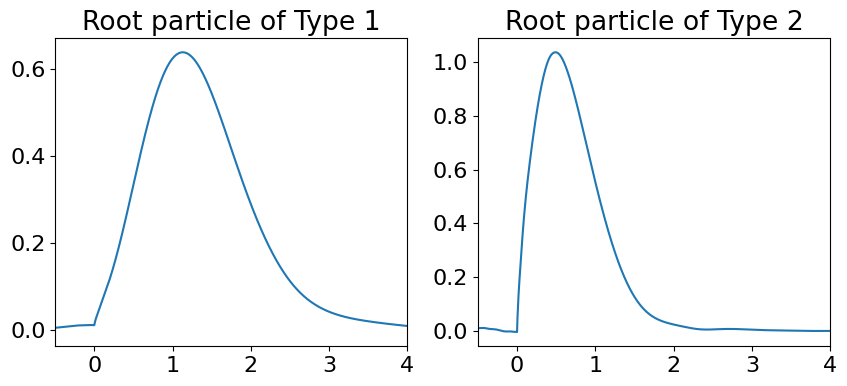

In [32]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
axes[0].plot(x_range, f_og1.real)
# axes[0].plot(x_range, f_og1.imag)
axes[0].set_title("Root particle of Type 1")
axes[1].plot(x_range, f_og2.real)
# axes[1].plot(x_range, f_og2.imag)
axes[1].set_title("Root particle of Type 2")
plt.setp(axes, xlim=(-0.5, 4))
# fig.suptitle("Density of W", y = 1.02)
# plt.savefig('w_dens2.pdf', bbox_inches='tight')
plt.show()

## Sampling from the density of W

In [35]:
# x range has to be non-negative
above0 = x_range >= 0
x_zero = x_range[above0]
y_zero1 = f_og1[above0]
y_zero2 = f_og2[above0]

# Where density is relevant
non_zero1 = y_zero1 > 0.00001
non_zero2 = y_zero2 > 0.00001
x1 = x_zero[non_zero1]
y1 = y_zero1[non_zero1].real
x2 = x_zero[non_zero2]
y2 = y_zero2[non_zero2].real

# Function for sampling from W
def sample_W(xs, dens, nb_samples, extinct = 0):
    rescaled_dens = dens/sum(dens)
    samples = np.random.choice(xs, p = rescaled_dens, size = nb_samples)
#     randomly replace samples with 0 according to the extinction probability
    if extinct != 0:
        which_died = np.random.binomial(n=1, p=extinct, size = nb_samples)
        samples[which_died == 1] = 0
    return samples

w1 = sample_W(x1, y1, 10000, qs[0])
w2 = sample_W(x2, y2, 10000, qs[1])

### Comparison of the estimated density with density by simulation

In [40]:
# Function for sampling the population size in the next generation of the process
def sample_Z(probabilities, n_samples):
#     Sample from the probabilities of the joint distribution matrix
    sampled = np.random.choice(len(probabilities), p=probabilities, size=n_samples)
#     Decipher to which row and column the sample corresponds
    rows = np.floor_divide(sampled, max_offspring)
    cols =  np.remainder(sampled, max_offspring)
    output = np.vstack((rows, cols))
    return output

# Number of generations to simulate
gens = 20
# Rescaling for the limiting distribution
rescaling = max_eigen**(gens)
# Simulate population sizes for the process and store the population size at the last generation
def simulate_last(probab):
    population_size = np.zeros((k, gens+1), dtype=int)
    population_size[i0-1,0] = 1
    for gen in range(gens):
        if sum(population_size[:, gen]) != 0:
            for typ in range(k):
                sampled = sample_Z(probab[typ], population_size[typ, gen])
                population_size[0,gen+1] += sum(sampled[0,:])
                population_size[1,gen+1] += sum(sampled[1,:])
        else:
            last_gener = [0, 0]
    if sum(population_size[:, -1]) != 0:
        last_gener = population_size[:, -1]
    return [last_gener[0], last_gener[1]]

# Number of simulations
nb_sims = 10000
results = np.zeros((2, nb_sims))
for sim in range(nb_sims):
    sim_results = simulate_last(all_probs)
    results[0:2, sim] = sim_results/rescaling

Plot of the inversted density and the density of rescaled population obtained by simulation.

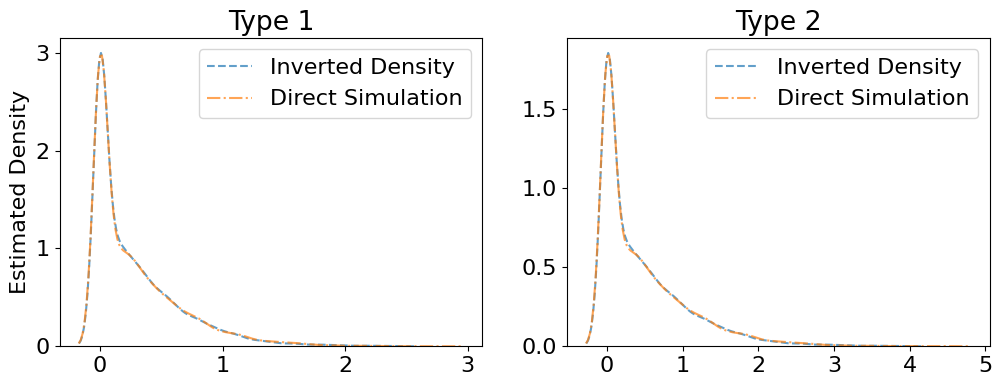

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i in range(2):
    sns.kdeplot(l[i]*w1, ax=axes[i], label="Inverted Density", linestyle="--", alpha=0.7)
    sns.kdeplot(results[i, :], ax=axes[i], label="Direct Simulation", linestyle="-.", alpha=0.7)
    axes[i].set_title("Type "+str(i+1))
    axes[i].legend()
axes[0].set_ylabel("Estimated Density")
axes[1].set_ylabel(None)
# plt.suptitle("Comparison of samples from density with simulation")
# plt.savefig('comparison.pdf', bbox_inches='tight')
plt.show()

1000 samples from simulation. 5000 samples from W1.

In [50]:
# Parameters for the following plot
# Making sure the bins are the same for samples from the inverted density and the simulation
nb_bins = 30
# Maximum sample
max1 = max(max(results[0,:]), max(l[0]*w1))
max2 = max(max(results[1,:]), max(l[1]*w1))
# Choosing the same bins
bin_edges1 = np.linspace(0, max1, nb_bins)
bin_edges2 = np.linspace(0, max2, nb_bins)
hist1_fourier, bins1 = np.histogram(l[1]*w1, bins=nb_bins, range=(0, max2), density=True)
hist1_sim, _ = np.histogram(results[1,:], bins=nb_bins, range=(0, max2), density=True)

# X ranges for both particle types
maxs = [max(max(results[0,:]), max(l[0]*w1)), max(max(results[1,:]), max(l[1]*w1))]

fig, axes = plt.subplots(3, 2, figsize=(12, 8))
for i in range(2):
    axes[0,i].hist(l[i]*w1, bins = bin_edges1, alpha=0.2, density=True, label="Inverted Density")
    axes[0,i].set_title("Inverted Density (Type " + str(i+1) +")")
for i in range(2):
    axes[1,i].hist(results[i, :], bins=bin_edges1, alpha=0.2, color="red", density=True, 
                   label="Direct Simulation")
    axes[1,i].set_title("Simulation (Type " + str(i+1) + ")")
for i in range(2):
    hist_fourier, bins = np.histogram(l[i]*w1, bins=nb_bins, range=(0, maxs[i]), density=True)
    hist_sim, _ = np.histogram(results[i,:], bins=nb_bins, range=(0, maxs[i]), density=True)
    axes[2,i].bar(bins[:-1], hist_fourier - hist_sim, width=np.diff(bins) ,edgecolor="black")
    axes[2,i].set_title("Histogram Difference for Type " + str(i+1))
plt.tight_layout()
# plt.savefig('images/histograms.pdf', bbox_inches='tight')
plt.show()

In [70]:
# Selecting non zero population sizes
results0  = results[0, results[0,:]!=0]
results1  = results[1, results[1,:]!=0]
w0 = w1[w1 !=0]
# Selecting the first 5000 non-zero population sizes
last = 5000
results01 = [results0[:last], results1[:last]]

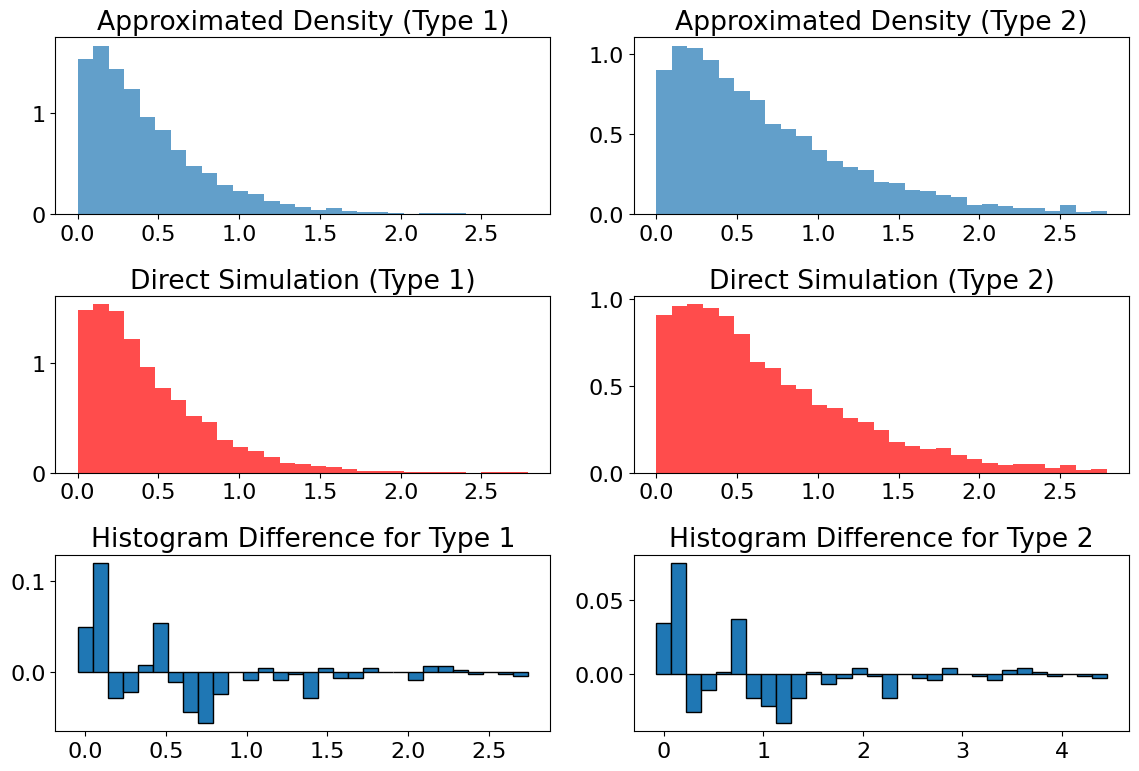

In [73]:
# X ranges for both particle types
maxs = [max(max(results0[:last]), max(l[0]*w0)), max(max(results1[:last]), max(l[1]*w0))]

fig, axes = plt.subplots(3, 2, figsize=(12, 8))
for i in range(2):
    axes[0,i].hist(l[i]*w0[:last], bins = bin_edges1, alpha=0.7, density=True, label="Inverted Density")
    axes[0,i].set_title("Approximated Density (Type " + str(i+1) +")")
for i in range(2):
    axes[1,i].hist(results01[i], bins=bin_edges1, alpha=0.7, color="red", density=True, 
                   label="Direct Simulation")
    axes[1,i].set_title("Direct Simulation (Type " + str(i+1) + ")")
for i in range(2):
    hist_fourier, bins = np.histogram(l[i]*w0[:last], bins=nb_bins, range=(0, maxs[i]), density=True)
    hist_sim, _ = np.histogram(results01[i], bins=nb_bins, range=(0, maxs[i]), density=True)
    axes[2,i].bar(bins[:-1], hist_fourier - hist_sim, width=np.diff(bins) ,edgecolor="black")
    axes[2,i].set_title("Histogram Difference for Type " + str(i+1))
plt.tight_layout()
plt.savefig('images/histograms.pdf', bbox_inches='tight')
plt.show()

## Coalescence probability approximation

In [41]:
# Maximum generation of interest
max_t = 10
# Number of simulations
nb_sim = 1000

# Coalescence probability approximation
def mean_for_type(pop_size):
    sm_w = 0
    # Sample from the inverted density
    while sm_w == 0:
        samples1 = np.random.choice(w1, int(pop_size[0]))
        samples2 = np.random.choice(w2, int(pop_size[1]))
        all_samples = np.concatenate(([samples1], [samples2]), axis =1)
        sm_w = np.sum(all_samples)
#         Numerator of the formula
    top = np.sum(all_samples**k)
#     Denominator of the formula
    bottom = (np.sum(all_samples))**k
#     The formula
    p_estim_dens = top/bottom
    return p_estim_dens

In [43]:
# Average transformed w per generation
p_aver_dens = np.ones((nb_sim, max_t))
# Definitely coalesced in generation 0
error_w = np.zeros(max_t)
current_sim = 0

while current_sim < nb_sim:
    population_sim = np.zeros((2, max_t), dtype = np.int64)
    population_sim[0,0] = 1
    for gen in range(1, max_t):
        for typ in range(2):
            children = sample_Z(all_probs[typ], population_sim[typ, gen-1])
            population_sim[0,gen] += sum(children[0,:])
            population_sim[1,gen] += sum(children[1,:])
#         Compute the formula for that given population size
    if sum(population_sim[:, max_t-1]) != 0:
#         print(population_sim)
        for gen in range(1, max_t):
#         Keeps the first element as 1 since the indexing starts from 1 and not 0
            p_aver_dens[current_sim, gen] = mean_for_type(population_sim[:, gen])
        current_sim += 1

formula = np.mean(p_aver_dens, axis=0)

# Error bars
for gen in range(max_t):
    error_w[gen] = t*np.std(p_aver_dens[:, gen])/math.sqrt(len(p_aver_dens))

# Genealogy simulation

#### Constants

In [34]:
# First generation
first_gen = 1
# Last generation
last_gen = 10
# Generation of the sample
extra_gens = 10
# Number of simulations
nb_sims = 1000

In [ ]:
# Empty vector for the proportion of the samples that coalesced
proportion_coalesced = np.ones(last_gen-first_gen+1)
error_bar = np.zeros(last_gen-first_gen+1)
# Loop over the generation of interest
for gen_ancestry in range(first_gen, last_gen+1):
    print("Running generation of interest" + str(gen_ancestry))
#     If they share an ancestor
    same_ancestor = np.full(nb_sims, 2)
#     Loop over the number of simulations
    for sim in range(nb_sims):
#         Population sizes for the future
        population_sim = np.zeros((2, last_gen+extra_gens), dtype = np.int64)
#     Single rootancestor of type i0
        population_sim[i0-1,0] = 1
#     Simulate only the population size on (0, t)
        for gen in range(1, gen_ancestry+1):
            for typ in range(2):
    #         Number of children sampling
                sampled = sample_Z(all_probs[typ], population_sim[typ, gen-1])
                population_sim[0,gen] += sum(sampled[0,:])
                population_sim[1,gen] += sum(sampled[1,:])
# Enumerate all the possible ancestors at the starting generation

        ancestors1 = np.arange(0, population_sim[0, gen_ancestry], dtype = np.int64)
        ancestors2 = np.arange(population_sim[0, gen_ancestry], 
                               population_sim[0, gen_ancestry]+population_sim[1,gen_ancestry], dtype = np.int64)
#         For all generations in the future of the starting generation
        for gen in range(gen_ancestry+1, last_gen+extra_gens):
            if population_sim[:, gen-1].sum() != 0:
                for typ in range(2):
        #         Number of children sampling
                    sampled = sample_Z(all_probs[typ], population_sim[typ, gen-1])
                    population_sim[0,gen] += sum(sampled[0,:])
                    population_sim[1,gen] += sum(sampled[1,:])
        #         Ancestors in the new generation
                    if typ == 0: 
                        new_ancestors11 = np.repeat(ancestors1, sampled[0,:])
                        new_ancestors12 = np.repeat(ancestors1, sampled[1,:])
                    if typ == 1:
                        new_ancestors21 = np.repeat(ancestors2, sampled[0,:])
                        new_ancestors22 = np.repeat(ancestors2, sampled[1,:])
                ancestors1 = np.concatenate((new_ancestors11, new_ancestors21))
                ancestors2 = np.concatenate((new_ancestors12, new_ancestors22))
        ancestors = np.concatenate((ancestors1, ancestors2))
#         If non-zero population, sample from last generation
        if population_sim[:, last_gen+extra_gens-1].sum() != 0:
            X = random.choices(range(0, ancestors.shape[0]), k=2)
            same_ancestor[sim] = (ancestors[X[0]] == ancestors[X[1]])
#     Remove extinct populations
    non_zero = same_ancestor[same_ancestor != 2]
    proportion_coalesced[gen_ancestry-1] = np.mean(non_zero)
    error_bar[gen_ancestry-1] = t*np.std(non_zero)/math.sqrt(len(non_zero))

Running generation of interest1
Running generation of interest2
Running generation of interest3
Running generation of interest4


In [48]:
# proportion_coalesced = np.concatenate((np.ones(1), proportion_coalesced))
# error_bar = np.concatenate((np.zeros(1), error_bar))

# Save proportion coalesced
# np.savetxt("data/prop_coalesced1000_10gens_8extra.csv", proportion_coalesced, delimiter=",")
# proportion_coalesced = np.genfromtxt('prop_coalesced250.csv', delimiter=',')

# Save error bars
# np.savetxt("data/error_genealogy1000_10gens_8extra.csv", error_bar, delimiter=",")
# error_bar = np.genfromtxt('error_genealogy250.csv', delimiter=',')